In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

df = yf.download("AMZN", start="2012-01-01", end="2024-01-01")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2012-01-03,8.9515,8.9740,8.7775,8.7945,102216000
2012-01-04,8.8755,9.0250,8.8035,8.9605,84104000
2012-01-05,8.8805,8.9125,8.7025,8.7970,76182000
2012-01-06,9.1305,9.2325,8.8750,8.9035,140168000
2012-01-09,8.9280,9.2185,8.8500,9.1380,101138000


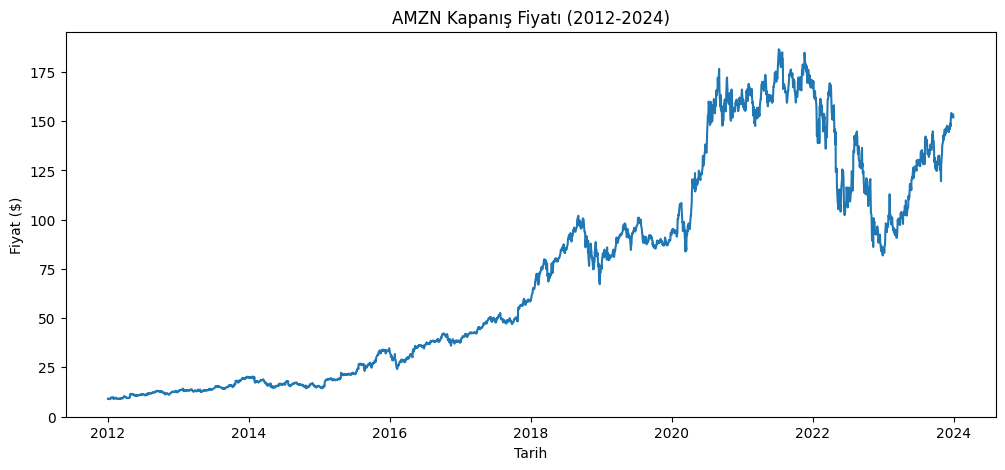

Ticker         AMZN
count   3018.000000
mean      72.523247
std       53.956645
min        8.796500
25%       18.760625
50%       59.735750
75%      114.268002
max      186.570496


In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.title("AMZN Kapanış Fiyatı (2012-2024)")
plt.xlabel("Tarih")
plt.ylabel("Fiyat ($)")
plt.show()

print(df["Close"].describe())

In [3]:
from sklearn.preprocessing import MinMaxScaler

close_prices = df[["Close"]].values

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

print(scaled_prices[:5])

[[-0.99825622]
 [-0.99911124]
 [-0.99905498]
 [-0.99624242]
 [-0.99852059]]


In [4]:
def create_sequences(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_prices, lookback)

print("X shape:", X.shape)  # (örnek sayısı, 20, 1)
print("y shape:", y.shape)  # (örnek sayısı, 1)

X shape: (2998, 20, 1)
y shape: (2998, 1)


In [5]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2398, 20, 1) (2398, 1)
Test: (600, 20, 1) (600, 1)


In [6]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

torch.Size([2398, 20, 1]) torch.Size([2398, 1])
